In [1]:
#@title import dataset
import pandas as pd
#lettura file
df= pd.read_csv('AI_machine_learning_data_set.csv') # Legge il file CSV e lo salva in un DataFrame
df.head() #legge i primi 5 valori per un check

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:

#@title visualizzazione dati

print("\n--INFORMAZIONI DATASET:--") #informazioni su dataset
df.info()

print("\n--VALORI MANCANTI:--") #controllo valori mancanti
print(df.isnull().sum())

print("\n--DIMENSIONE DATASET:--") #analisi dimensione dataset
print(df.shape)

print("\n--CONTEGGIO FRODI:--") #analisi del numero di frodi (variabile target)
print(df['isFraud'].value_counts())

#calcolo percentuale frodi
fraud_count=df['isFraud'].value_counts()[1]
total_rows=df.shape[0]
fraud_percentage=fraud_count / total_rows * 100
print(f"\n--PERCENTUALE FRODI: {fraud_percentage: .2f}%--")


--INFORMAZIONI DATASET:--
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB

--VALORI MANCANTI:--
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

--DIMENSIONE DATASET:--
(6362620, 11)

--CONTEGGIO FRODI:--
isFraud
0    6354407
1       8213
Name: count, dtype: int64

--PERCENTUALE FRODI:  0.13%--


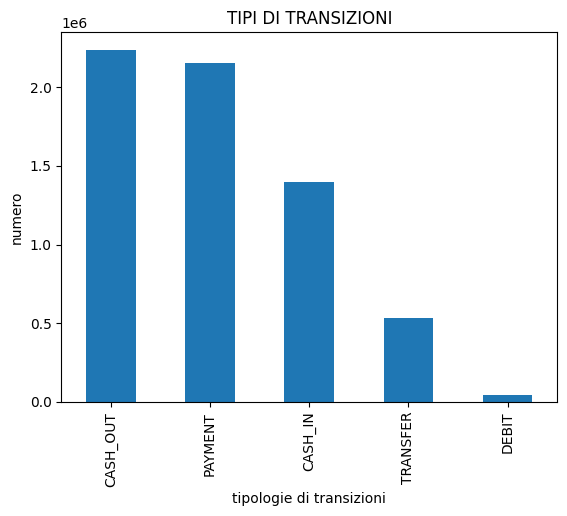

In [3]:
#@title visualizzazione grafica dati

import matplotlib.pyplot as plt

# grafico transazioni
df['type'].value_counts().plot(kind='bar')
plt.title('TIPI DI TRANSIZIONI')
plt.xlabel('tipologie di transizioni')
plt.ylabel('numero')
plt.show()

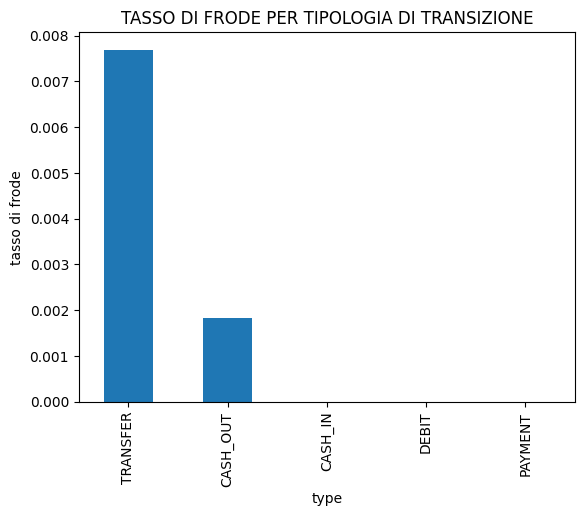

In [4]:
# @title
# grafico tassi di frode per tipo
fraud_by_type=df\
               .groupby('type')['isFraud']\
               .mean()\
               .sort_values(ascending=False)

fraud_by_type.plot(kind='bar',title='TASSO DI FRODE PER TIPOLOGIA DI TRANSIZIONE')
plt.ylabel("tasso di frode")
plt.show()

#grafico soglia amount se c'è frode (x quantita, y se è o non è una frode) un grafico per tipo

Text(0.5, 1.0, 'Matrice di Correlazione')

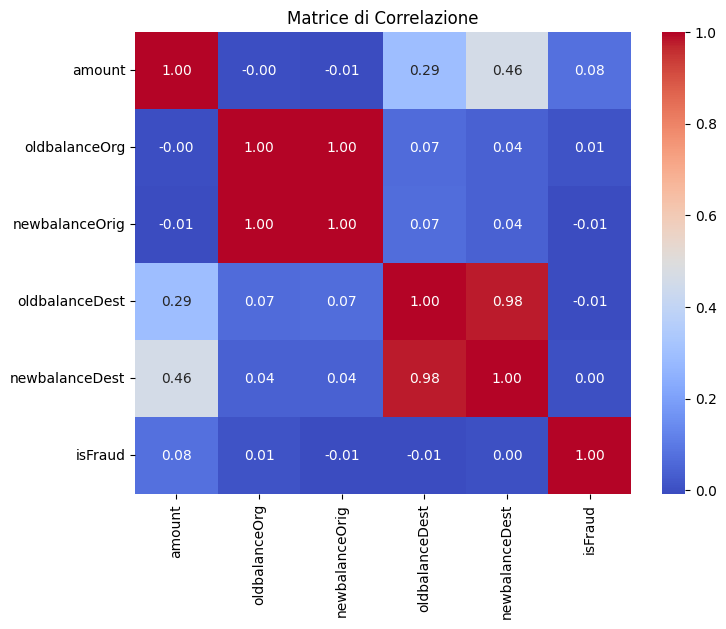

In [5]:
#matrice correlazione
#colonne rilevanti e isFraud

import seaborn as sns

numeric_cols = ['amount' , 'oldbalanceOrg' , 'newbalanceOrig' , 'oldbalanceDest' , 'newbalanceDest' , 'isFraud']
correlation_matrix = df[numeric_cols].corr()

#heatmap creazione e visualizazione
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix , annot=True , cmap='coolwarm' , fmt=".2f")
plt.title('Matrice di Correlazione')


In [6]:
#  nuovo dataframe
# tempo, nomi dei mittenti/destinatari e 'isFlaggedFraud' non servono per il modello predittivo
#creazione dataframe senza colonne
df_model = df.drop(['step' , 'nameOrig' , 'nameDest' , 'isFlaggedFraud'], axis=1)
 #rimuovere dest e new balance org
print("\nNUOVO DATASET")
print("Dimensioni:", df_model.shape)
df_model.head()



NUOVO DATASET
Dimensioni: (6362620, 7)


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [17]:
# divisione training e test set
from sklearn.model_selection import train_test_split

#separazione bersaglio da dati
y=df_model['isFraud']
x=df_model.drop('isFraud', axis=1)

#divisione test e train
x_train , x_test , y_train , y_test =train_test_split(x,y, test_size=0.3 , stratify=y)

# 1. Uniamo momentaneamente X_train e y_train per fare il campionamento
df_train_completo = pd.concat([x_train, y_train], axis=1)

# 2. Separiamo le frodi dalle transazioni lecite nel training set
frodi_train = df_train_completo[df_train_completo['isFraud'] == 1]
non_frodi_train = df_train_completo[df_train_completo['isFraud'] == 0]

# 3. Selezioniamo CASUALMENTE un numero di transazioni lecite pari al numero di frodi
# Questo è l'under-sampling brutale richiesto dal professore
non_frodi_bilanciate = non_frodi_train.sample(n=len(frodi_train), random_state=42)

# 4. Uniamo i due blocchi per ottenere il nuovo training set perfettamente bilanciato (50% e 50%)
df_train_bilanciato = pd.concat([frodi_train, non_frodi_bilanciate]).sample(frac=1, random_state=42)

# 5. Riassegniamo le variabili X e Y bilanciate che useremo per l'addestramento
x_train_bilanciato = df_train_bilanciato.drop('isFraud', axis=1)
y_train_bilanciato = df_train_bilanciato['isFraud']

# Verifichiamo il bilanciamento stampando i nuovi conteggi
print("--- NUOVO CONTEGGIO BILANCIATO NEL TRAINING SET ---")
print(y_train_bilanciato.value_counts())

print(f"Training set: {x_train.shape}")
print(f"Test set: {x_test.shape}")

--- NUOVO CONTEGGIO BILANCIATO NEL TRAINING SET ---
isFraud
1    5749
0    5749
Name: count, dtype: int64
Training set: (4453834, 6)
Test set: (1908786, 6)


In [18]:
y.head()

0    0
1    0
2    1
3    1
4    0
Name: isFraud, dtype: int64

In [19]:
# pre-elaborazione
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#quali colonne sono numeriche e quali testuali
categorical =['type']
numeric =['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', ]

#preprocessatore (column transformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),numeric),
        ('cat', OneHotEncoder(drop='first'),categorical)
        ],
    remainder='drop'
)

#assemblamento pipeline
pipeline= Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('classifier', LogisticRegression( max_iter=1000))
])

print("Pipeline creata con successo")

Pipeline creata con successo


In [20]:
# allenamento pipeline

print("addestramento pipeline in corso")
pipeline.fit(x_train, y_train)
print ("addestramento completato")


addestramento pipeline in corso
addestramento completato


In [21]:
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [22]:
# calcolo previsioni
y_pred = pipeline.predict(x_test)

#stampa report
print("REPORT:")
print(classification_report(y_test, y_pred))

#matrice di confusione
cm = confusion_matrix(y_test, y_pred)

#DataFrame con etichette per righe e colonne
cm_con_titoli = pd.DataFrame(cm, 
                             columns=['PREDETTO LECITO', 'PREDETTO FRODE'], 
                             index=['REALE LECITO', 'REALE FRODE'])

#Stampa a schermo della matrice formattata
print("\nMATRICE DI CONFUSIONE:")
print(cm_con_titoli)

#cacolo accuratezza
accuracy=pipeline.score(x_test, y_test) #mettere label su m atrice confusione
print(f"\nACCURATEZZA GLOBALE: { accuracy: .2%}")

REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.87      0.35      0.50      2464

    accuracy                           1.00   1908786
   macro avg       0.93      0.68      0.75   1908786
weighted avg       1.00      1.00      1.00   1908786


MATRICE DI CONFUSIONE:
              PREDETTO LECITO  PREDETTO FRODE
REALE LECITO          1906188             134
REALE FRODE              1597             867

ACCURATEZZA GLOBALE:  99.91%


In [23]:
# esportazione pipeline
import joblib

#esportazione pipeline in un file
joblib.dump(pipeline,'fraud_detection_pipeline.pickle')
print("Modello salvato con successo")



Modello salvato con successo
